# Dependencies

In [65]:
#dependencies and libraries
!pip install nibabel -q

import os
import random
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_DIR = '/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData'

# Verifying the structure of dataset

In [66]:
# Opening first patient's folder to verify the structure

patient_folders = sorted(os.listdir(DATA_DIR))
first_patient = patient_folders[0]
first_patient_path = os.path.join(DATA_DIR, first_patient)

print(f"Total Patients Found: {len(patient_folders)}")
print(f"Files inside {first_patient}:")

for file in sorted(os.listdir(first_patient_path)):
    print(f" - {file}")

Total Patients Found: 371
Files inside BraTS20_Training_001:
 - BraTS20_Training_001_flair.nii
 - BraTS20_Training_001_seg.nii
 - BraTS20_Training_001_t1.nii
 - BraTS20_Training_001_t1ce.nii
 - BraTS20_Training_001_t2.nii


# Loading the Dataset and skipping the instance which has missing information.

 Skipping corrupted/missing patient: BraTS20_Training_355

 Total valid patients loaded: 368
 Skipping corrupted/missing patient: BraTS20_Training_355
Tensor Shapes -> Image: torch.Size([1, 240, 240]) | Mask: torch.Size([1, 240, 240])


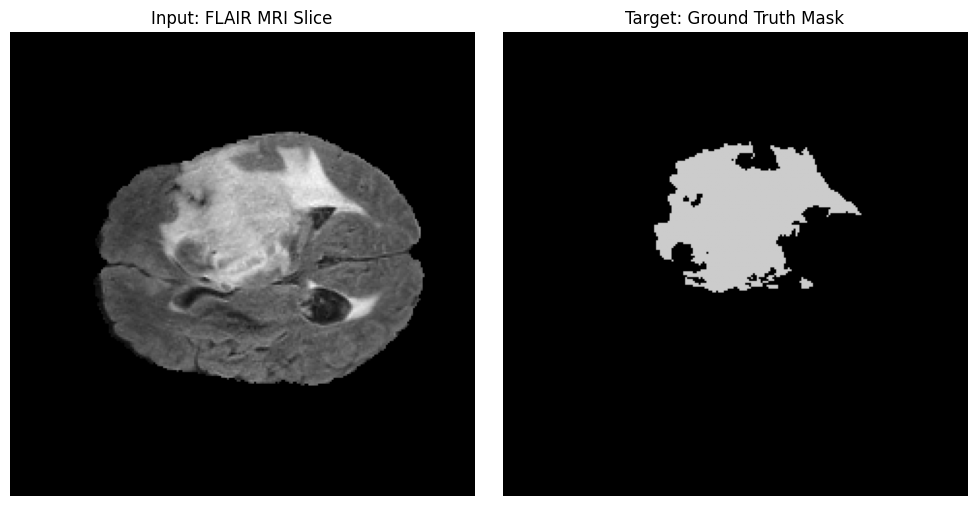

In [67]:
class BraTS2DDataset(Dataset):
    def __init__(self, data_dir, slice_idx=75):
        self.data_dir = data_dir
        self.slice_idx = slice_idx
        self.patient_folders = []
        
        # skip the corrupted ones
        for f in sorted(os.listdir(data_dir)):
            patient_path = os.path.join(data_dir, f)
            if os.path.isdir(patient_path):
                patient_id = os.path.basename(patient_path)
                flair_path = os.path.join(patient_path, f"{patient_id}_flair.nii")
                mask_path = os.path.join(patient_path, f"{patient_id}_seg.nii")
                
                # Only add the patient to the roster if BOTH files actually exist
                if os.path.exists(flair_path) and os.path.exists(mask_path):
                    self.patient_folders.append(patient_path)
                else:
                    print(f" Skipping corrupted/missing patient: {patient_id}")
                    
    def __len__(self):
        return len(self.patient_folders)
    
    def __getitem__(self, idx):
        patient_path = self.patient_folders[idx]
        patient_id = os.path.basename(patient_path)
        
        flair_path = os.path.join(patient_path, f"{patient_id}_flair.nii")
        mask_path = os.path.join(patient_path, f"{patient_id}_seg.nii")
        
        flair_vol = nib.load(flair_path).get_fdata()
        mask_vol = nib.load(mask_path).get_fdata()
        
        flair_slice = flair_vol[:, :, self.slice_idx]
        mask_slice = mask_vol[:, :, self.slice_idx]
        
        if flair_slice.max() > 0:
            flair_slice = flair_slice / flair_slice.max()
            
        mask_slice = np.where(mask_slice > 0, 1.0, 0.0)
        
        img_tensor = torch.tensor(flair_slice, dtype=torch.float32).unsqueeze(0)
        mask_tensor = torch.tensor(mask_slice, dtype=torch.float32).unsqueeze(0)
        
        return img_tensor, mask_tensor

# Test it
dataset = BraTS2DDataset(DATA_DIR, slice_idx=75)
print(f"\n Total valid patients loaded: {len(dataset)}")
# visualizing one sample
dataset = BraTS2DDataset(DATA_DIR, slice_idx=75)
sample_img, sample_mask = dataset[0]

print(f"Tensor Shapes -> Image: {sample_img.shape} | Mask: {sample_mask.shape}")

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(sample_img.squeeze(), cmap='gray')
axes[0].set_title("Input: FLAIR MRI Slice")
axes[0].axis('off')

axes[1].imshow(sample_mask.squeeze(), cmap='nipy_spectral')
axes[1].set_title("Target: Ground Truth Mask")
axes[1].axis('off')

plt.tight_layout()
plt.show()

# The Model Architecture

In [70]:
class DoubleConv(nn.Module):
    """The Conv -> BatchNorm -> ReLU repeated twice."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            # bias=False because BatchNorm cancels out biases anyway (saves memory)
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    """
    A fully dynamic U-Net. 
    Pass any list of feature sizes to scale the model up or down.
    """
    def __init__(self, in_channels=1, out_channels=1, features=[64, 128, 256, 512]):
        super().__init__()
        self.ups = nn.ModuleList()
        self.downs = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # 1. Contracting Path (Encoder)
        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature

        # 2. Expansive Path (Decoder)
        for feature in reversed(features):
            # Up-convolution (halves channels, doubles spatial dimensions)
            self.ups.append(nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2))
            self.ups.append(DoubleConv(feature*2, feature))

        # 3. Bottleneck
        self.bottleneck = DoubleConv(features[-1], features[-1]*2)

        # 4. Final Output Layer
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        # Run the Encoder
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        # Run the Bottleneck
        x = self.bottleneck(x)
        
        # Reverse skip connections for the Decoder path
        skip_connections = skip_connections[::-1]

        # Run the Decoder
        for i in range(0, len(self.ups), 2):
            x = self.ups[i](x) # Upsample
            skip_connection = skip_connections[i//2]

            # The Parity fix: Resolve rounding errors from downsampling
            if x.shape != skip_connection.shape:
                x = F.interpolate(x, size=skip_connection.shape[2:], mode="bilinear", align_corners=True)

            # Concatenate skip connection
            concat_skip = torch.cat((skip_connection, x), dim=1)
            x = self.ups[i+1](concat_skip)

        # Output raw logits
        return self.final_conv(x)

# Training and Validation

Dataset Split: 294 Training Brains | 74 Validation Brains
Initiating U-Net Training Sequence

Epoch [01/10] | Train Loss: 0.8902 | Val Loss: 0.9275
Epoch [02/10] | Train Loss: 0.8601 | Val Loss: 0.8591
Epoch [03/10] | Train Loss: 0.8448 | Val Loss: 0.8568
Epoch [04/10] | Train Loss: 0.8362 | Val Loss: 0.8377
Epoch [05/10] | Train Loss: 0.8313 | Val Loss: 0.8487
Epoch [06/10] | Train Loss: 0.8220 | Val Loss: 0.8432
Epoch [07/10] | Train Loss: 0.8177 | Val Loss: 0.8300
Epoch [08/10] | Train Loss: 0.8148 | Val Loss: 0.8153
Epoch [09/10] | Train Loss: 0.8044 | Val Loss: 0.8259
Epoch [10/10] | Train Loss: 0.8005 | Val Loss: 0.8178


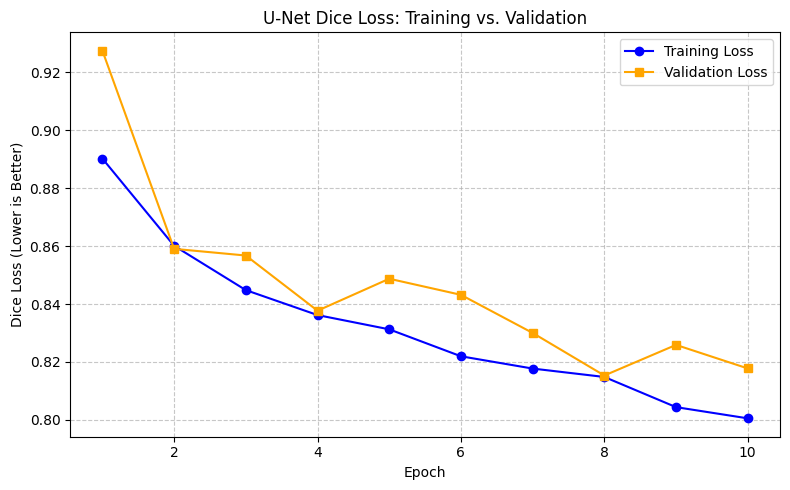

In [71]:
#  The Custom Loss Function
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, inputs, targets):
        inputs = torch.sigmoid(inputs)
        inputs = inputs.view(-1)
        targets = targets.view(-1)
        
        intersection = (inputs * targets).sum()                            
        dice = (2. * intersection + self.smooth) / (inputs.sum() + targets.sum() + self.smooth)  
        return 1 - dice

# Hyperparameters & Train/Test Split
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
EPOCHS = 10

#Split the dataset
total_patients = len(dataset)
train_size = int(0.8 * total_patients)
val_size = total_patients - train_size

train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,num_workers=2)

print(f"Dataset Split: {len(train_dataset)} Training Brains | {len(val_dataset)} Validation Brains")

# Initialize Model, Optimizer, and Loss
model = UNet(in_channels=1, out_channels=1, features=[64, 128, 256, 512]).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = DiceLoss()

train_loss_history = []
val_loss_history = []

# 3. The Training & Validation Loop
print("Initiating U-Net Training Sequence\n")

for epoch in range(EPOCHS):
    
    # Training part
    model.train()
    epoch_train_loss = 0
    for images, masks in train_loader:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        
        optimizer.zero_grad()
        predictions = model(images)
        loss = criterion(predictions, masks)
        loss.backward()
        optimizer.step()
        
        epoch_train_loss += loss.item()
        
    avg_train_loss = epoch_train_loss / len(train_loader)
    train_loss_history.append(avg_train_loss)
    
    # Validation part
    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            predictions = model(images)
            loss = criterion(predictions, masks)
            epoch_val_loss += loss.item()
            
    avg_val_loss = epoch_val_loss / len(val_loader)
    val_loss_history.append(avg_val_loss)
    
    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

# Plotting the Learning Curves
plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS+1), train_loss_history, label='Training Loss', marker='o', color='blue')
plt.plot(range(1, EPOCHS+1), val_loss_history, label='Validation Loss', marker='s', color='orange')
plt.title('U-Net Dice Loss: Training vs. Validation')
plt.xlabel('Epoch')
plt.ylabel('Dice Loss (Lower is Better)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Visualising some results of the model

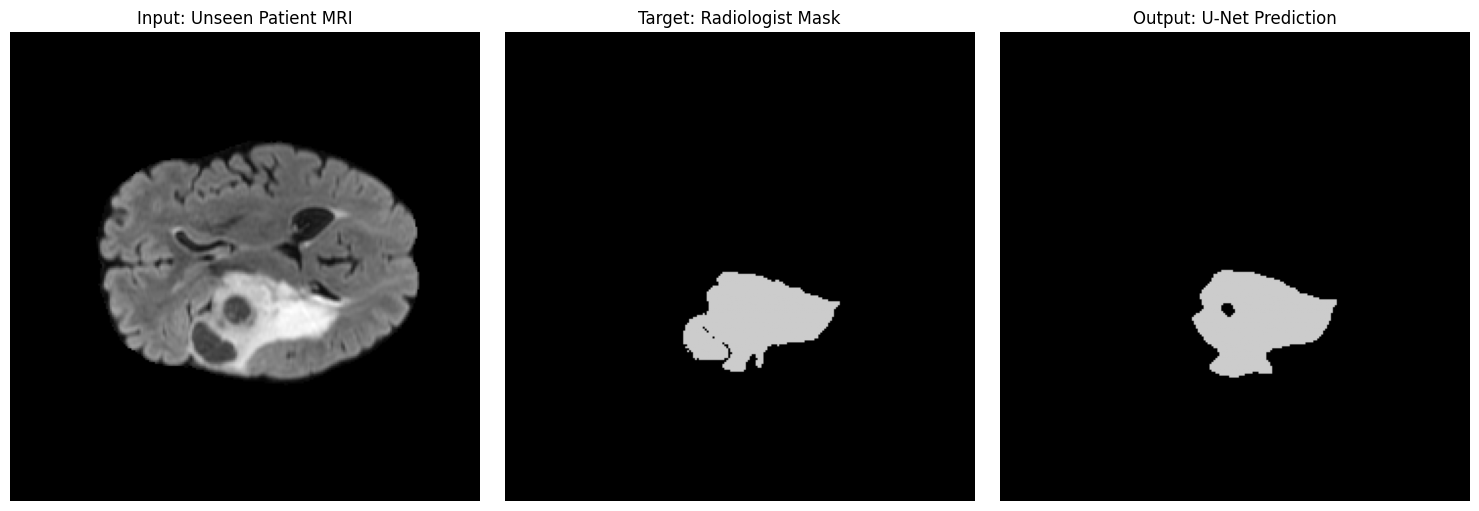

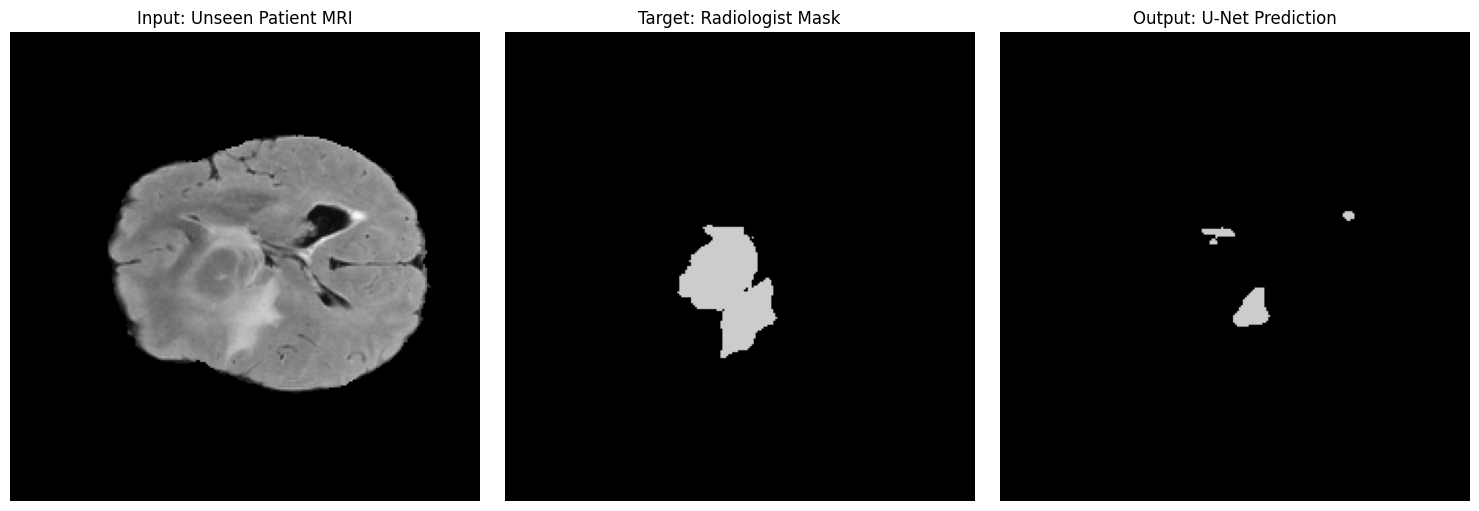

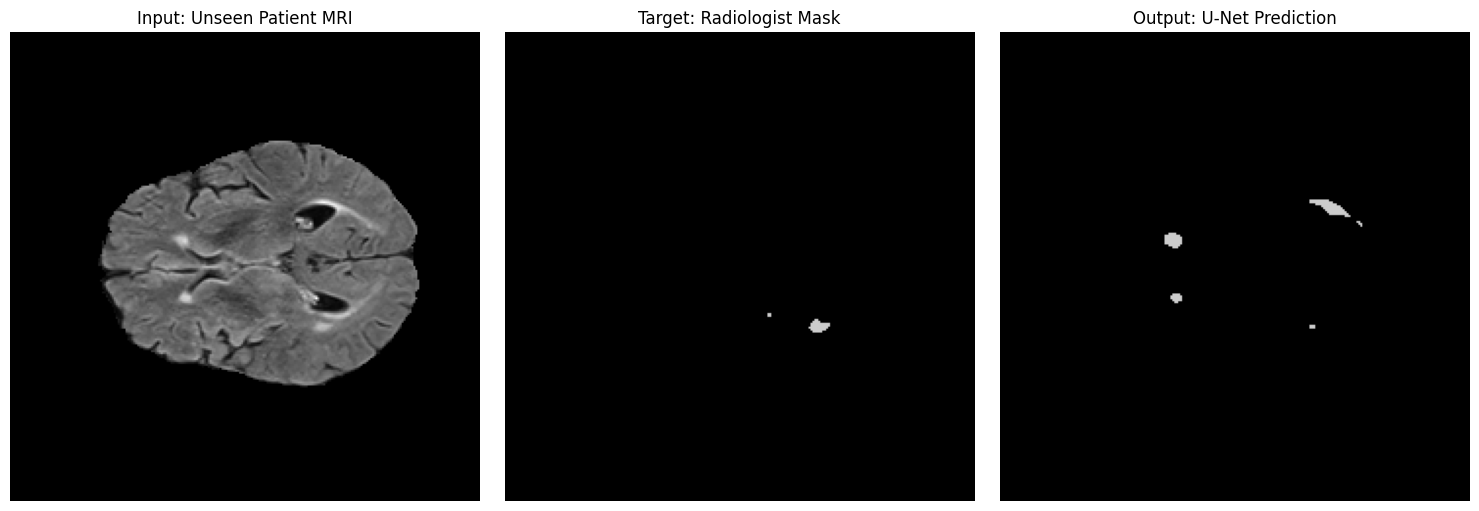

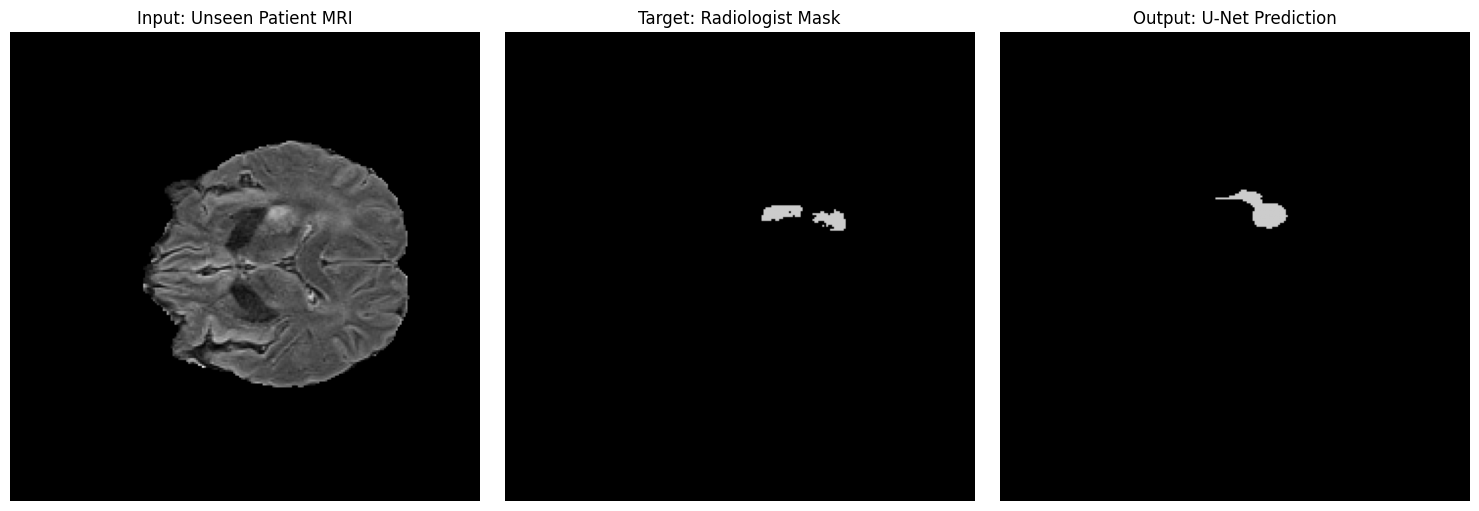

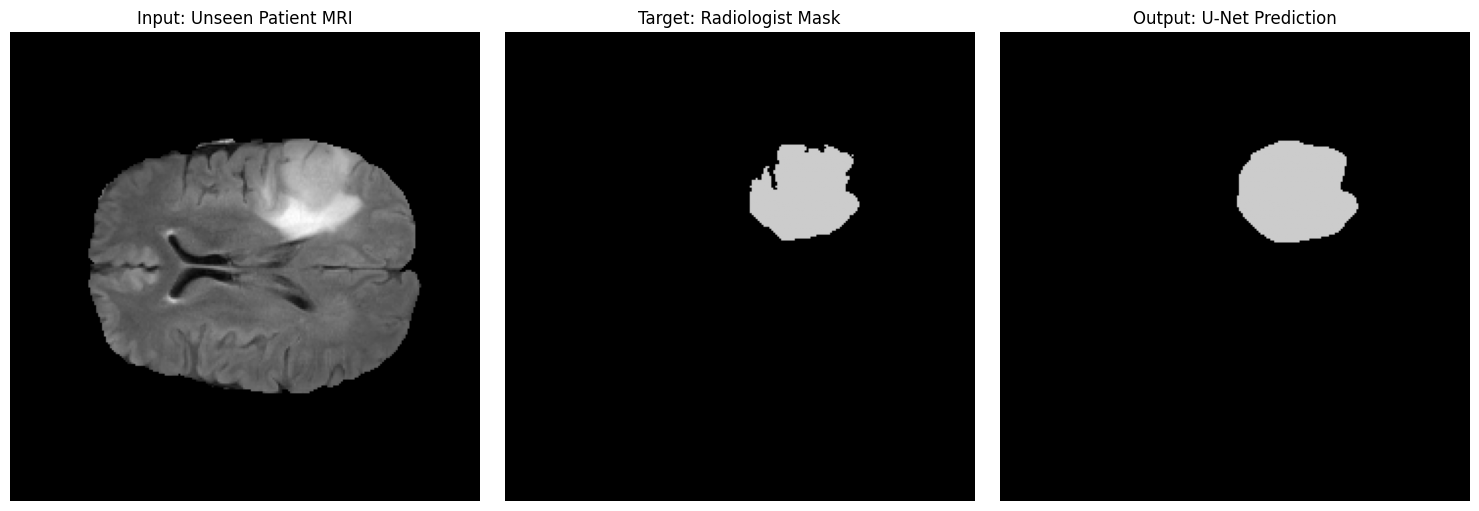

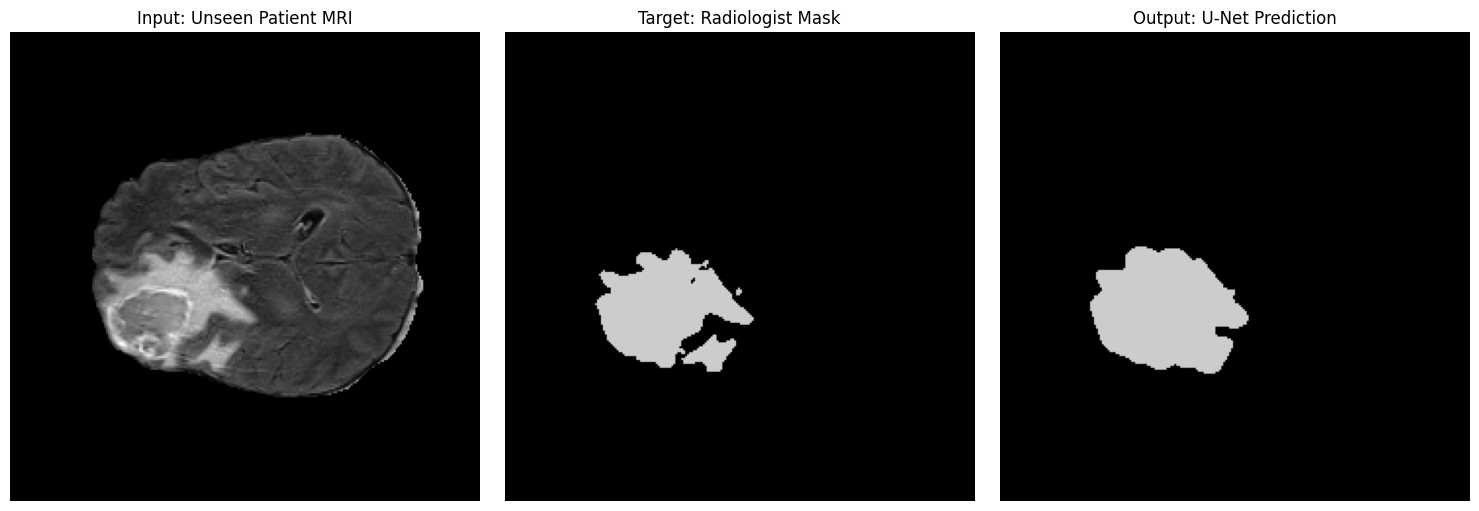

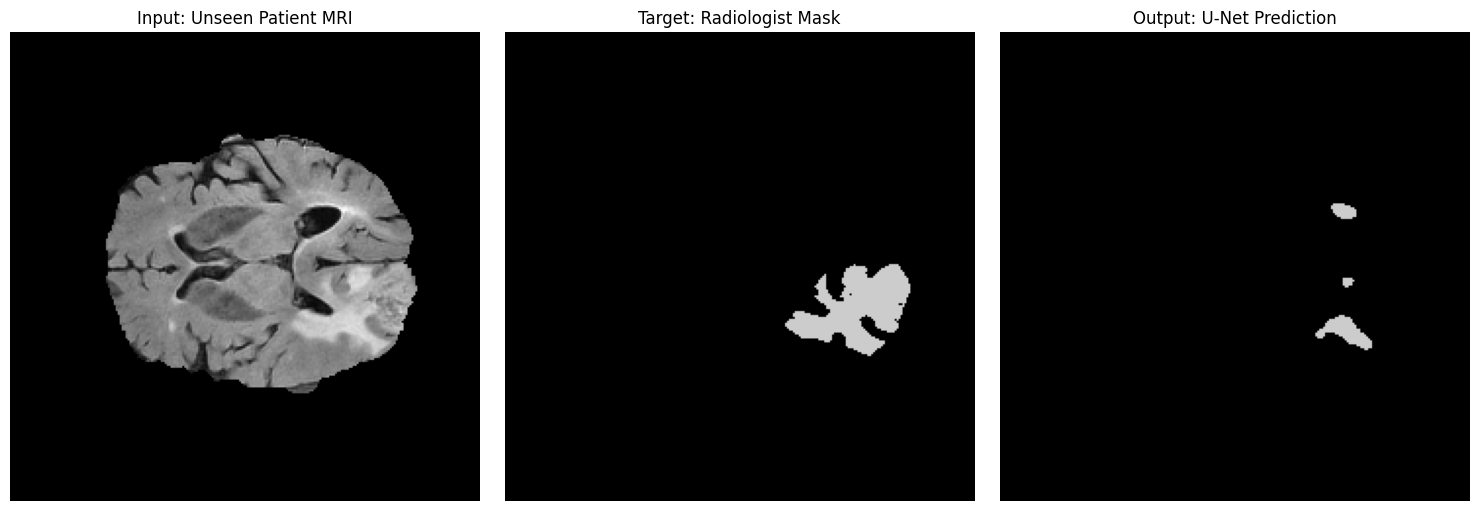

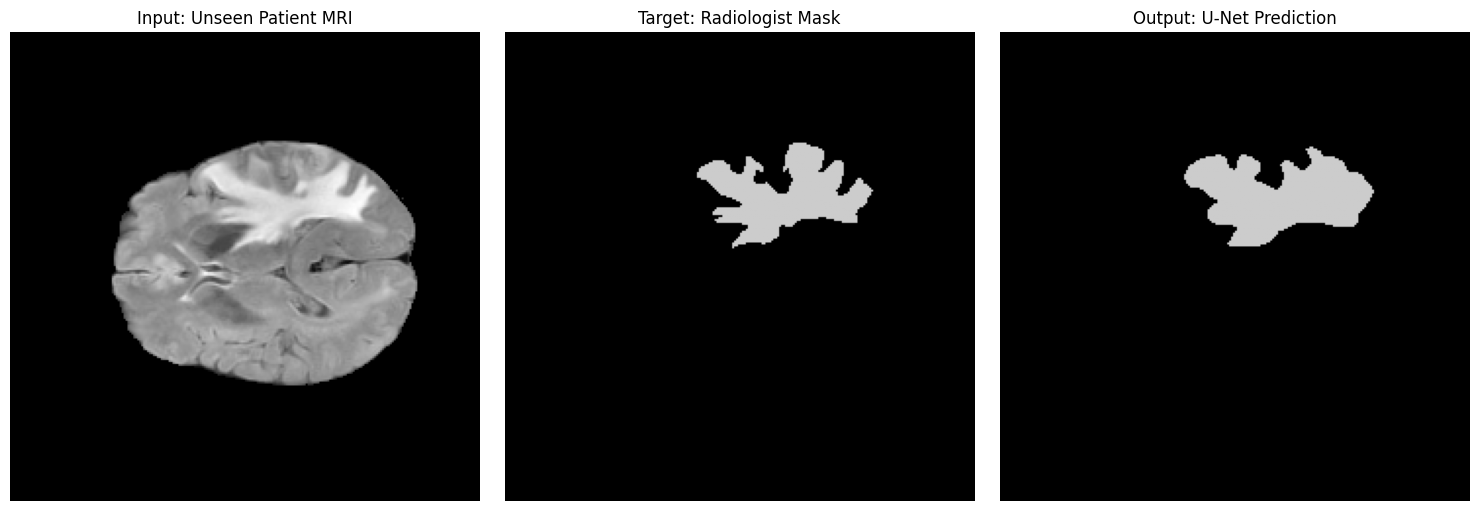

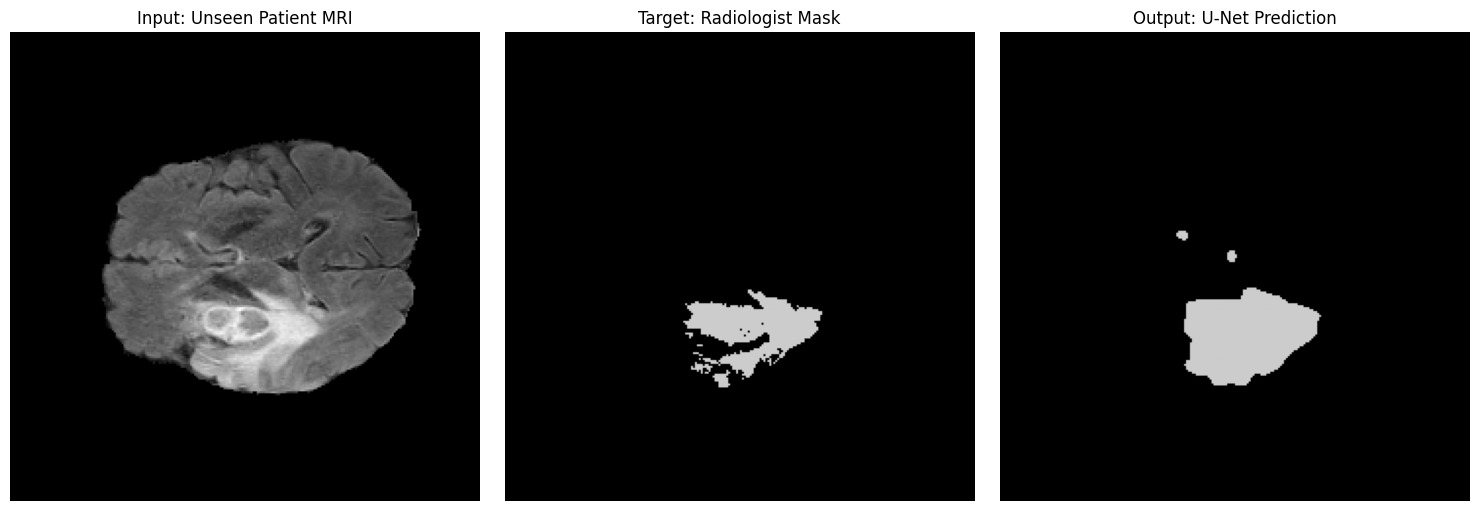

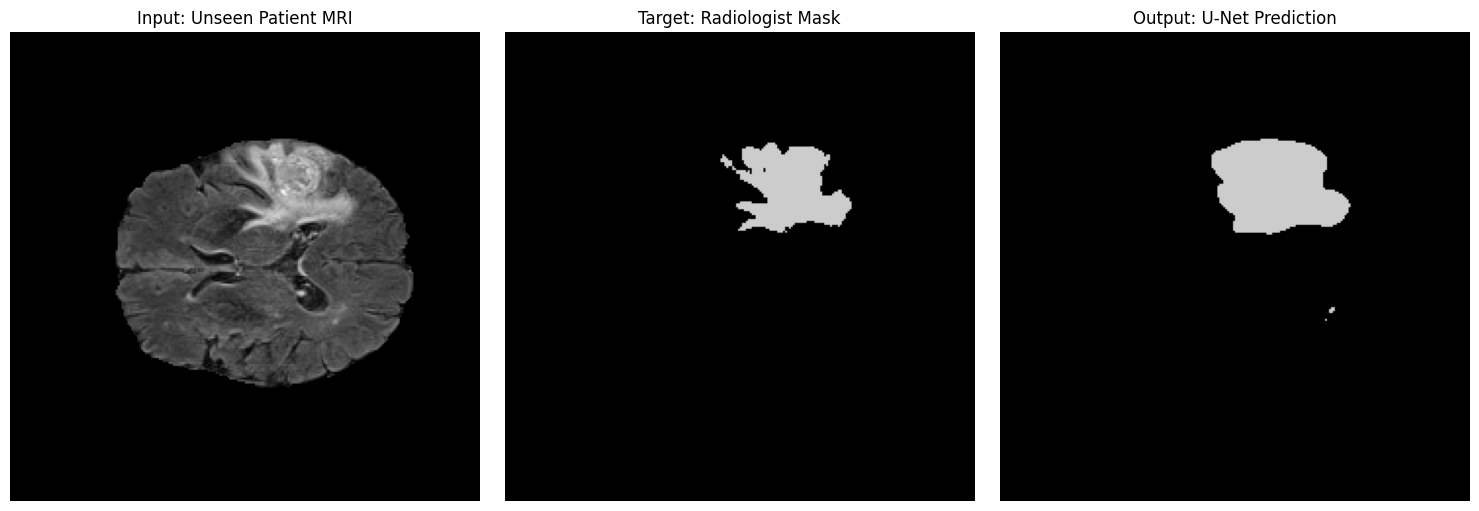

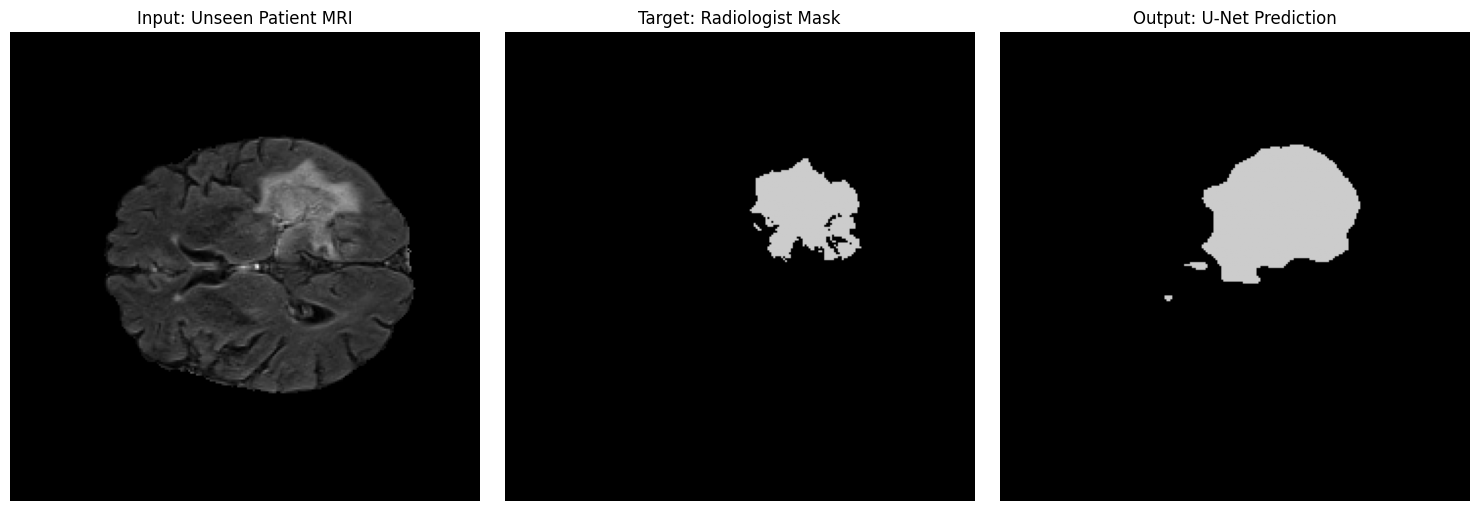

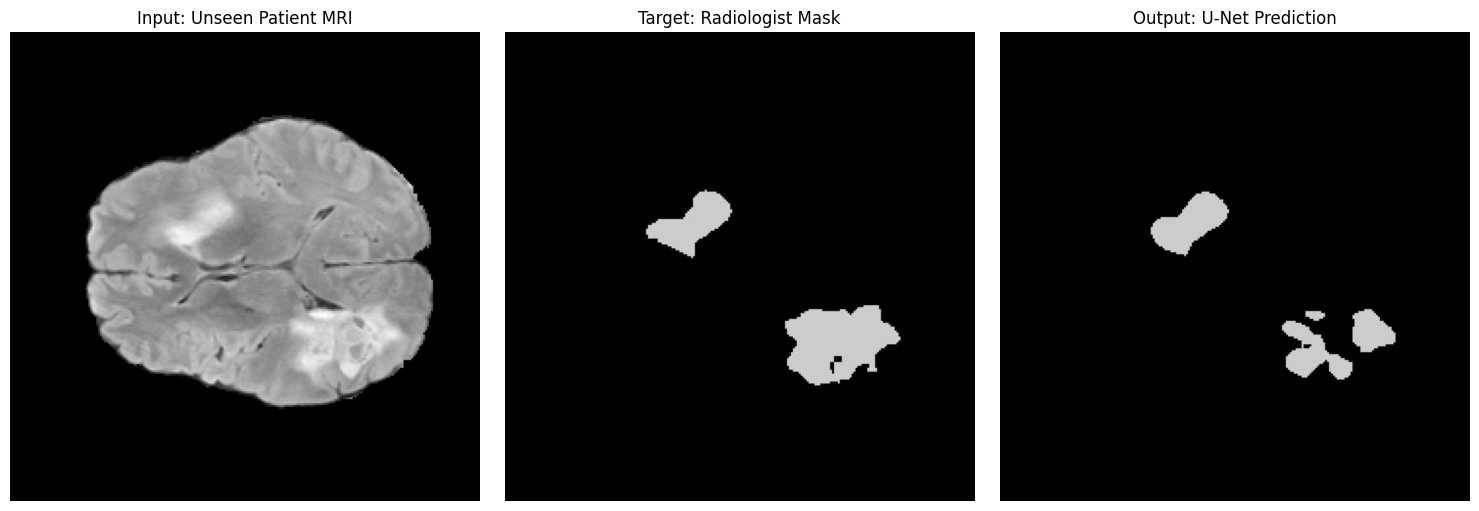

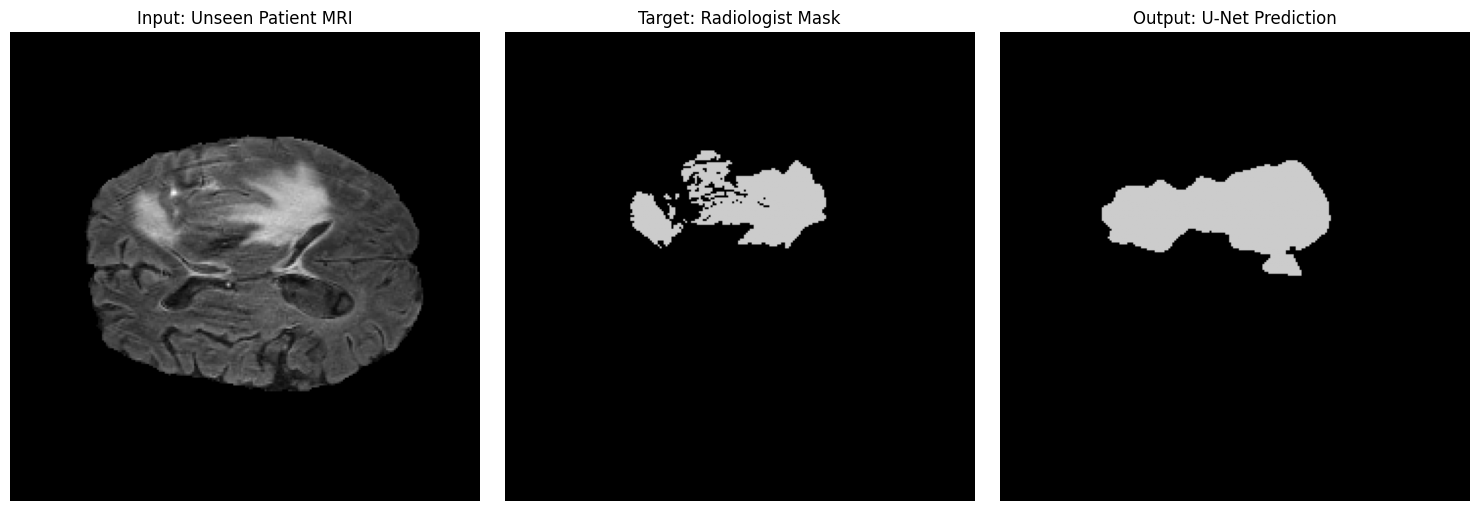

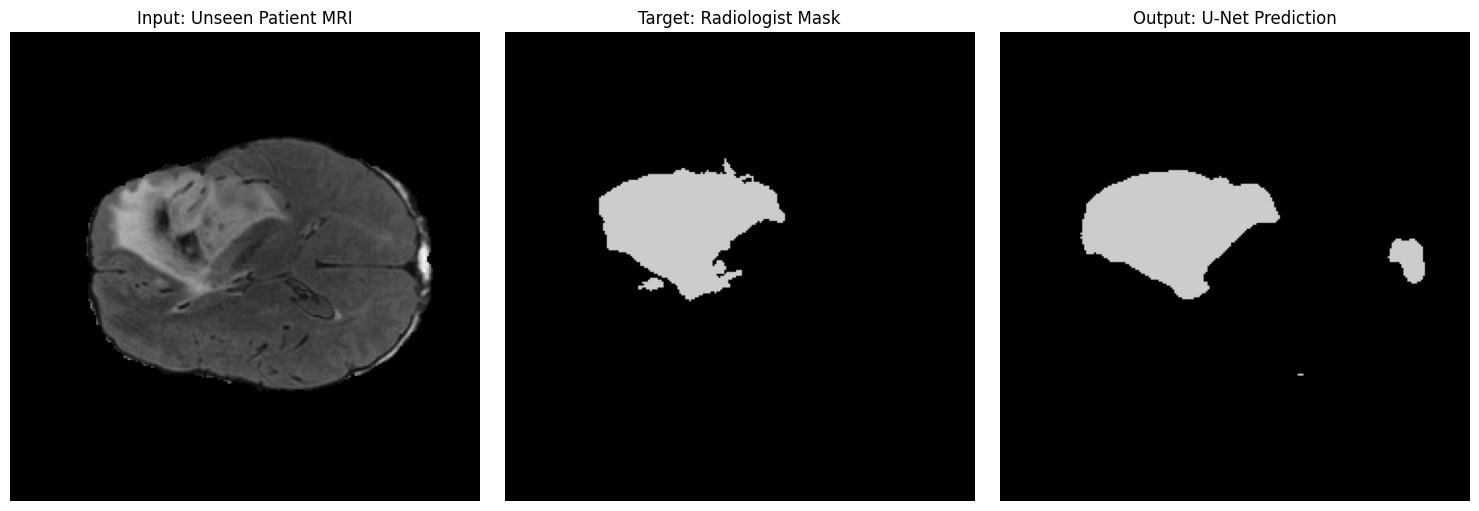

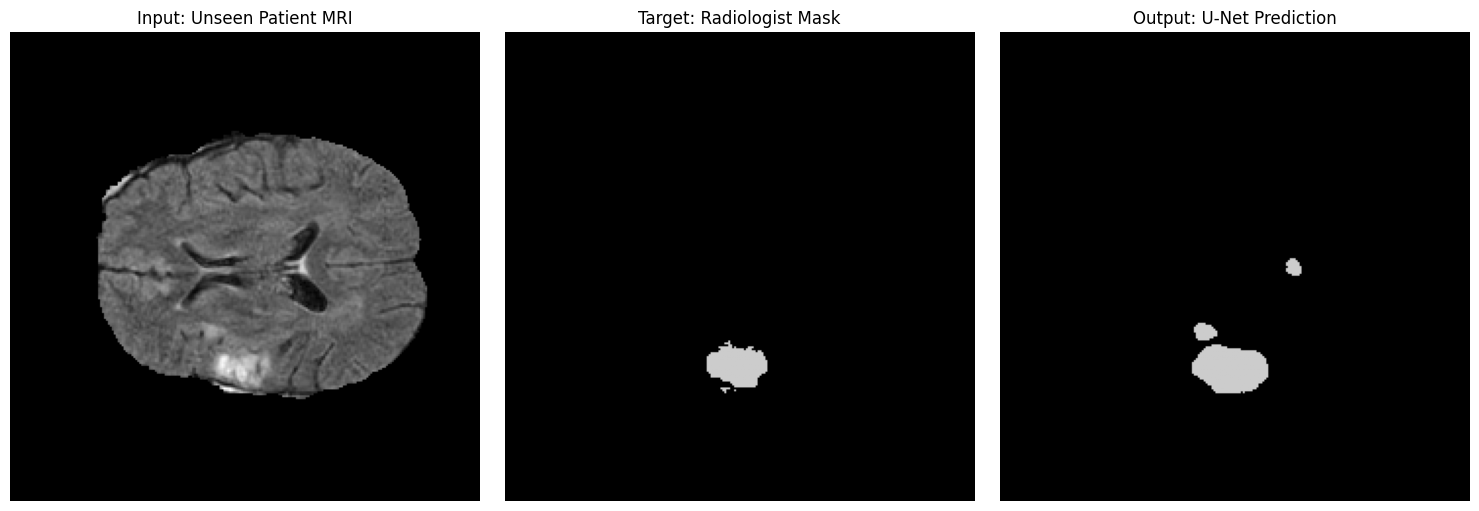

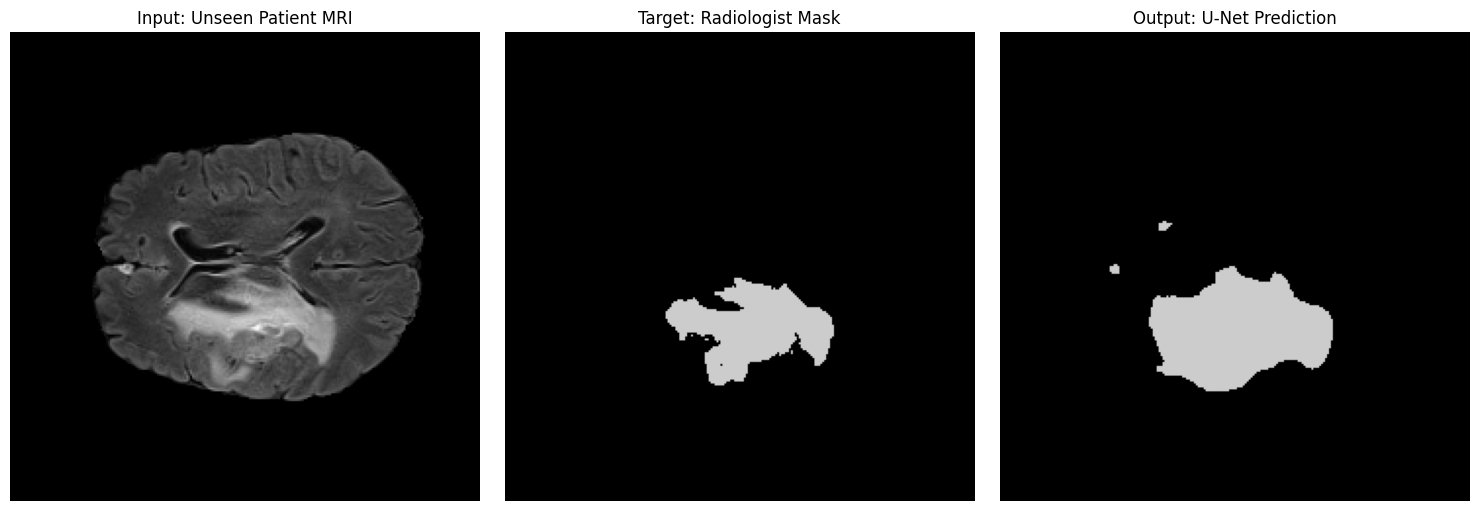

In [72]:
model.eval() 

# Grab a single batch from the unseen validation data
images, masks = next(iter(val_loader))
#displaying all predicted results for the given Batch
for i in range(len(images)):
    sample_img = images[i].unsqueeze(0).to(DEVICE) # Shape: (1, 1, 240, 240)
    sample_mask = masks[i].squeeze().cpu().numpy() # The Radiologist's true mask
    
    # Inference
    with torch.no_grad():
        raw_prediction = model(sample_img)
        prob_mask = torch.sigmoid(raw_prediction)
        binary_prediction = (prob_mask > 0.5).float().squeeze().cpu().numpy()
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(sample_img.squeeze().cpu().numpy(), cmap='gray')
    axes[0].set_title("Input: Unseen Patient MRI")
    axes[0].axis('off')
    
    axes[1].imshow(sample_mask, cmap='nipy_spectral')
    axes[1].set_title("Target: Radiologist Mask")
    axes[1].axis('off')
    
    axes[2].imshow(binary_prediction, cmap='nipy_spectral')
    axes[2].set_title("Output: U-Net Prediction")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# Storing the results (stored in output in Kaggle)

Securely stored 125 NIfTI predictions in: /kaggle/working/UnetModel_predictions

Visualizing 5 Random AI Predictions:


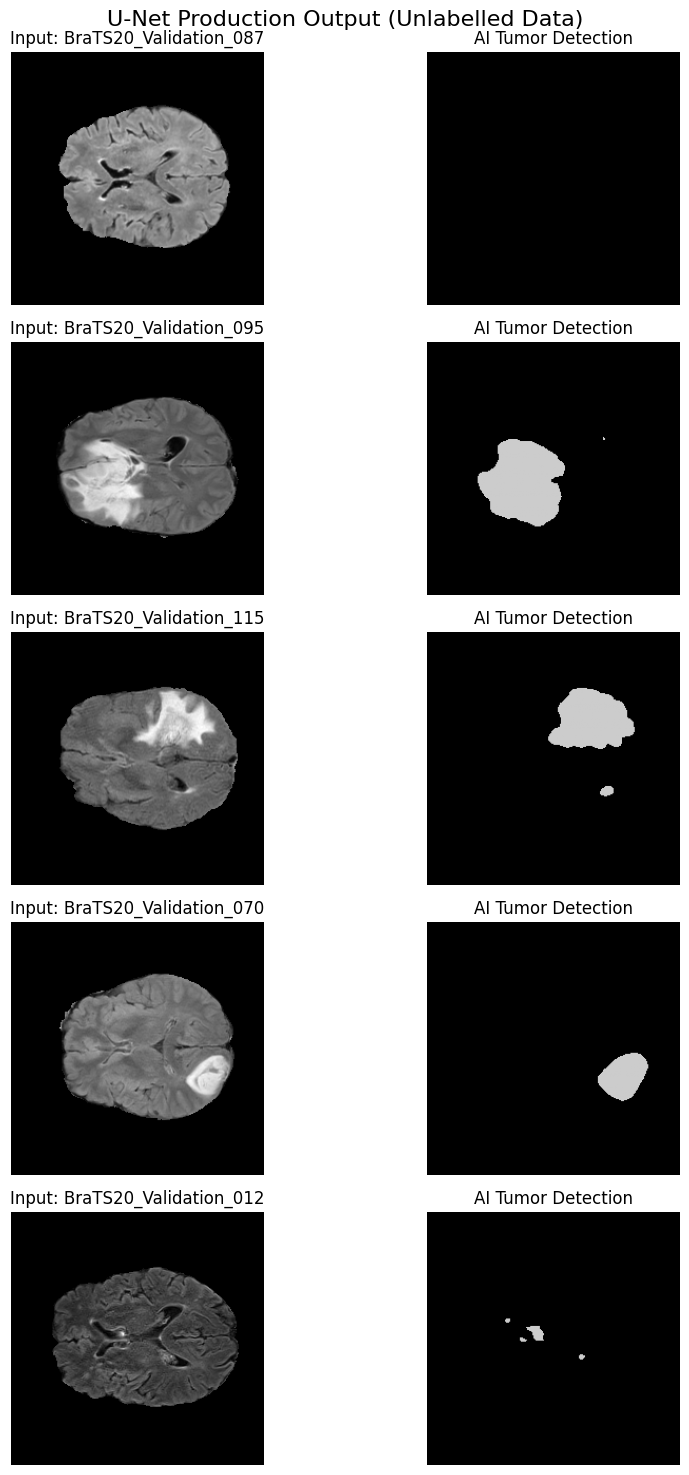

In [75]:
UNLABELLED_DIR = '/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData'
OUTPUT_DIR = '/kaggle/working/UnetModel_predictions'
os.makedirs(OUTPUT_DIR, exist_ok=True)

class PredictionDataset(Dataset):
    def __init__(self, data_dir, slice_idx=75):
        self.data_dir = data_dir
        self.slice_idx = slice_idx
        self.patient_folders = [
            os.path.join(data_dir, f) for f in sorted(os.listdir(data_dir)) 
            if os.path.isdir(os.path.join(data_dir, f))
        ]

    def __len__(self):
        return len(self.patient_folders)

    def __getitem__(self, idx):
        patient_path = self.patient_folders[idx]
        patient_id = os.path.basename(patient_path)
        flair_path = os.path.join(patient_path, f"{patient_id}_flair.nii")
        flair_vol = nib.load(flair_path).get_fdata()
        flair_slice = flair_vol[:, :, self.slice_idx]
        if flair_slice.max() > 0:
            flair_slice = flair_slice / flair_slice.max()
        img_tensor = torch.tensor(flair_slice, dtype=torch.float32).unsqueeze(0)
        return img_tensor, patient_id

prod_dataset = PredictionDataset(UNLABELLED_DIR)
prod_loader = DataLoader(prod_dataset, batch_size=1, shuffle=False)

model.eval()
stored_for_plot = []

with torch.no_grad():
    for img_tensor, patient_id in prod_loader:
        img_tensor = img_tensor.to(DEVICE)
        patient_id = patient_id[0]

        raw_pred = model(img_tensor)
        prob_mask = torch.sigmoid(raw_pred)
        binary_prediction = (prob_mask > 0.5).float().cpu().numpy().squeeze()

        save_path = os.path.join(OUTPUT_DIR, f"{patient_id}_AI_Mask.nii.gz")
        nib_img = nib.Nifti1Image(binary_prediction, affine=np.eye(4)) 
        nib.save(nib_img, save_path)

        stored_for_plot.append((patient_id, img_tensor.cpu().numpy().squeeze(), binary_prediction))

print(f"Securely stored {len(stored_for_plot)} NIfTI predictions in: {OUTPUT_DIR}")

# Visualize 5 Random Results
print("\nVisualizing 5 Random AI Predictions:")
random_samples = random.sample(stored_for_plot, min(5, len(stored_for_plot)))

fig, axes = plt.subplots(5, 2, figsize=(10, 15))
fig.suptitle("U-Net Production Output (Unlabelled Data)", fontsize=16, y=0.98)

for i, (pat_id, img, pred) in enumerate(random_samples):
    # Input
    axes[i, 0].imshow(img, cmap='gray')
    axes[i, 0].set_title(f"Input: {pat_id}")
    axes[i, 0].axis('off')
    
    # AI Output
    axes[i, 1].imshow(pred, cmap='nipy_spectral')
    axes[i, 1].set_title("AI Tumor Detection")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()